In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

## Own trained GPT2

This note book focuses on the sampling, and showing what adding temperture does to the output

In [3]:
import torch.nn as nn
import torch
from dataclasses import dataclass
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [4]:
class CasualSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embed % config.n_head == 0
        # Key, Value, Query for all heads but in one batch
        self.c_attn = nn.Linear(config.n_embed, 3 * config.n_embed)
        # output projection
        self.c_proj = nn.Linear(config.n_embed, config.n_embed)
        self.c_proj.NANOGPT_SCALE_INIT = 1

        self.n_head = config.n_head
        self.n_embd = config.n_embed

    def forward(self, x):
        B, T, C = x.size()  # batch size, sequence_len, embedding_dim n_embed
        # calculate the query, key and value for all heads in a batch and move forward to be the batch
        # nh is number of heads, hs is head size and c is number of channels
        # e.g. in GPT-2 (124M), n_heads = 12, hs=64, sonh*hs =C=768 in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # B,nh, T, ns
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # B,nh, T, ns
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # B,nh, T, ns
        # Attenion (materialisze the large T,T matrix for all the queryies and keys )
        # This is flash attention
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)

        y = (
            y.transpose(1, 2).contiguous().view(B, T, C)
        )  # Get back into the shape it came in
        return self.c_proj(y)


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embed, 4 * config.n_embed)
        self.gelu = nn.GELU(approximate="tanh")
        self.c_proj = nn.Linear(config.n_embed * 4, config.n_embed)
        self.c_proj.NANOGPT_SCALE_INIT = 1

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embed)
        self.attn = CasualSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embed)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))

        return x


@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = (
        50257  # number of tokens: 50,000 BPE merges = 256 byte tokens + 1 <|endoftext|>
    )
    n_layer: int = 12
    n_head: int = 12
    n_embed: int = 768


class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte=nn.Embedding(config.vocab_size, config.n_embed),
                wpe=nn.Embedding(config.block_size, config.n_embed),
                h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f=nn.LayerNorm(config.n_embed),
            )
        )
        self.lm_head = nn.Linear(config.n_embed, config.vocab_size, bias=False)
        # weight sharing
        self.transformer.wte.weight = self.lm_head.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, "NANOGPT_SCALE_INIT"):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        # idx is always B,T
        B, T = idx.size()
        assert (
            T <= self.config.block_size
        ), f"Cannot forward sequence of length {T}, block size is {config.block_size}"
        # forward the token and position embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        pos_emb = self.transformer.wpe(pos)  # positional embeddings of shape T,N-embed
        tok_emb = self.transformer.wte(idx)  # token embedding of shape B,T,n_embed
        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
            x = block(x)
        # forward through final layernorm and classifier
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)  # B,T,Vocab_size
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained model GPT-2 Model weights from huggingface"""
        assert model_type in {"gpt2", "gpt2-medium", "gpt2-large", "gpt2-xl"}
        from transformers import GPT2LMHeadModel

        print(f"Loading weights from pretrained gpt: { model_type}")
        config_args = {
            "gpt2": dict(n_layer=12, n_head=12, n_embed=768),  # 124M params
            "gpt2-medium": dict(n_layer=24, n_head=16, n_embed=1024),  # 350M params
            "gpt2-large": dict(n_layer=36, n_head=20, n_embed=1280),  # 774M params
            "gpt2-xl": dict(n_layer=48, n_head=25, n_embed=1600),  # 1558M params
        }[model_type]
        config_args["vocab_size"] = 50257  # always this for GPT model checkpoints
        config_args["block_size"] = (
            1024  # always this sequence length for GPT chekpoints
        )
        # create a sfrom scratch intialised minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [
            k for k in sd_keys if not k.endswith(".attn.bias")
        ]  # discard this mask / buffer

        # init a huggingface transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()
        # copy while ensuring all of the parameters are aligned and match in name and shapes
        sd_hf_keys = sd_hf.keys()
        sd_hf_keys = [
            k for k in sd_hf_keys if not k.endswith(".attn.masked_bias")
        ]  # discard this mask / buffer
        sd_hf_keys = [
            k for k in sd_hf_keys if not k.endswith(".attn.bias")
        ]  # discard this mask / buffer
        transposed = [
            "attn.c_attn.weight",
            "attn.c_proj.weight",
            "mlp.c_fc.weight",
            "mlp.c_proj.weight",
        ]
        assert len(sd_keys) == len(
            sd_hf_keys
        ), f"Mismatched length of keys {len(sd_keys)} != len(sd_hf_keys)"

        for k in sd_hf_keys:
            if any(k.endswith(w) for w in transposed):
                # special treatemnet for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])
        return model

    def configure_optimiser(self, weight_decay, lr, device):
        # start with all of the candidate parameters that require_grad
        param_dict = {pn: p for pn, p in self.named_parameters()}
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups, any params that is 2d will be weight decayed else we ignore
        # i.e. all weight tensors in matmuls + embeddings decay and al biases and layer norms wont
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        no_decay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {"params": decay_params, "weight_decay": weight_decay},
            {"params": no_decay_params, "weight_decay": 0.0},
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_no_decay_params = sum(p.numel() for p in no_decay_params)
        if master_process:
            print(f"Num of decay_params = {num_decay_params}")
            print(f"Num of no_decay_params = {num_no_decay_params}")
        fused_available = "fused" in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and "cuda" in device
        if master_process:
            print(f"Using fused adam {use_fused}")
        optimiser = torch.optim.AdamW(
            optim_groups, lr=lr, betas=(0.9, 0.96), eps=1e-8, fused=use_fused
        )
        return optimiser

In [5]:
device = "cpu"

In [6]:
model = GPT(GPTConfig(vocab_size=50304))
model.to(device)

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50304, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CasualSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50304, bias=False)
)

In [7]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")

## Temperature

Termperature Scaling, is a way of controlling the distribution of the probabilities in the logits, i.e. divide the logits by a numebr greater than 0. 

logits / temperarure_scalar

In [8]:
0.1 / 1, 0.1 / 0.5, 0.1 / 0.1, 0.5/0.1

(0.1, 0.2, 1.0, 5.0)

In [9]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return F.softmax(scaled_logits, dim=-1).squeeze()

In [10]:
tokens = enc.encode("Hello")
tokens =torch.tensor(tokens, dtype=torch.long)
tokens = tokens.unsqueeze(0).repeat(1, 1)
x = tokens.to(device)
with torch.no_grad():
    logits,_ = model(x)

we are getting the original 50 possible next tokens to choose

In [11]:
probs = F.softmax(logits, dim=-1)
#do top k sampling, k=50
top_k_probs, top_k_indices = torch.topk(probs, 50, dim=-1)

In [12]:
keys = [enc.decode([i]) for i in top_k_indices.squeeze().tolist()]

In [13]:
keys

[' Yin',
 ' months',
 'abis',
 ' �',
 'UC',
 ' subpoena',
 ' 369',
 'eenth',
 ' tel',
 'Luck',
 'clear',
 'か',
 'arbon',
 'ystem',
 ' Influence',
 'itri',
 ' GTA',
 ' buddy',
 ' chromosomes',
 ' Rough',
 ' rent',
 ' prostitution',
 'DA',
 ' Order',
 ' Moh',
 'eca',
 'Though',
 ' Kaufman',
 'ック',
 'tailed',
 ' territories',
 ' clarified',
 'follow',
 ' Jamaica',
 'iologist',
 ' budget',
 'ARB',
 ' compassionate',
 ' Pyramid',
 ' lottery',
 ' Save',
 ' ar',
 ' infection',
 ' Pse',
 ' circulating',
 ' SCH',
 'backs',
 'Senator',
 ' landslide',
 ' 414']

In [15]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return F.softmax(scaled_logits, dim=-1).squeeze()

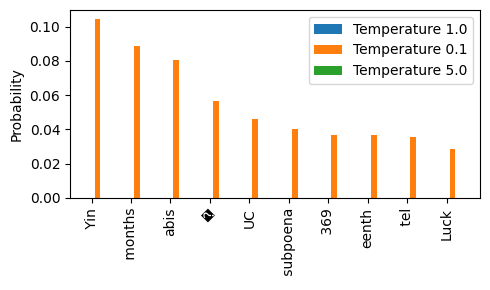

In [16]:
temperatures = [1.,0.1, 5.]
scaled_probs = [softmax_with_temperature(logits, t) for t in temperatures]
n = 10
x = torch.arange(n)
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    s_l = scaled_probs[i][top_k_indices].squeeze()
    rects = ax.bar(x+i*bar_width, s_l[:n], bar_width, label=f"Temperature {T}")

ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(keys[:n], rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

Seems the temperature affects it are hard to see, so lets look at the generation 

In [17]:
#prefix tokens 
def sample(model, input_text="Hello I am a language model,", num_return_sequences=5, max_length=32, temperature=1.):
    tokens = enc.encode(input_text)
    tokens =torch.tensor(tokens, dtype=torch.long)
    tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) #5,8
    x = tokens.to(device)

    #Generate right now is b,T 
    torch.manual_seed(42)
    while x.size(1) < max_length:
        #forward the model to get the logits
        with torch.no_grad():
            logits,_ = model(x)
            #take the logits at the last position
            logits = logits[:,-1,:]
            
            logits /=temperature
            #get probs
            probs = F.softmax(logits, dim=-1)
            #do top k sampling, k=50
            top_k_probs, top_k_indices = torch.topk(probs, 50, dim=-1)
            #select a token from the topk probs
            ix = torch.multinomial(top_k_probs,1)
            #gather the corresponding indices
            xcol = torch.gather(top_k_indices, -1,ix)
            x = torch.cat((x,xcol),dim=1)

    for i in range(5):
        tokens = x[i].tolist()
        decoded = enc.decode(tokens)
        print(f"> {decoded}")

In [18]:
model_dict = torch.load('log/model_19072.pt', map_location=torch.device('cpu'), weights_only=False)

model.load_state_dict(model_dict['model'])

<All keys matched successfully>

In [19]:
for t in temperatures:
    print(f"Current temperature is {t}")
    sample(model, temperature=t)
    print("\n\n")

Current temperature is 1.0
> Hello I am a language model, and I know that every language model is unique. Your question is exactly similar to me, but the model also has many variables
> Hello I am a language model, that means in languages they don't recognize any kind of grammar rules, that we have to see these in everything that we've
> Hello I am a language model, the way the language works, is to use a tool like
http://t.co/fpZKgE
> Hello I am a language model, and so I know it is a language model what a computer really does if we have to translate and talk to your computer is
> Hello I am a language model, is when I say "I am the original", and not a language model. That is.
So the two things I



Current temperature is 0.1
> Hello I am a language model, and I am a language model. I am a language model. I am a language model. I am a language model.
> Hello I am a language model, and I am a language model. I am a language model. I am a language model. I am a language model.
> Hello 

Seems there can be extremes with temperature, 